### PYTHON-13. Визуализация данных

Пример. 

Таблица covid_data 

* date — дата наблюдения;
* province/state — наименование провинции/штата;
* country — наименование страны;
* confirmed — общее число зафиксированных случаев на указанный день;
* deaths — общее число зафиксированных смертей на указанный день;
* recovered — общее число выздоровлений на указанный день.


vaccinations_data таблица содержит следующие столбцы:

* country — наименование страны;
* date — дата наблюдения;
* total_vaccinations — общее число введённых вакцин в стране на указанный день;
* people_vaccinated — общее число привитых первым компонентом в стране на указанный день;
* people_vaccinated_per_hundred — процент привитых первым компонентом в стране на указанный день (рассчитывается как );
* people_fully_vaccinated — общее число привитых вторым компонентом в стране на указанный день (первый компонент уже был введён им ранее);
* people_fully_vaccinated_per_hundred — процент привитых вторым компонентом в стране на указанный день (рассчитывается как );
* daily_vaccination — ежедневная вакцинация (число вакцинированных в указанный день);
vaccines — комбинации вакцин, используемые в стране.


In [1]:
import pandas as pd 
#  данные о показателях заболеваемости за каждый день в различных регионах 187 стран
covid_data = pd.read_csv('data/covid/covid_data.csv')

#  данные о процессе вакцинирования людей в 221 стране мира.

vaccinations_data = pd.read_csv('data/vaccin/country_vaccinations.csv')
vaccinations_data = vaccinations_data[['country', 'date', 'total_vaccinations',
                                       'people_vaccinated', 'people_vaccinated_per_hundred',
                                       'people_fully_vaccinated', 'people_fully_vaccinated_per_hundred',
                                       'daily_vaccinations', 'vaccines']]
display(covid_data.head(3))
#covid_data.info()
display(vaccinations_data.head(5))


,date,province/state,country,confirmed,deaths,recovered
0,01/22/2020,Anhui,China,1.0,0.0,0.0
1,01/22/2020,Beijing,China,14.0,0.0,0.0
2,01/22/2020,Chongqing,China,6.0,0.0,0.0


,country,date,total_vaccinations,people_vaccinated,people_vaccinated_per_hundred,people_fully_vaccinated,people_fully_vaccinated_per_hundred,daily_vaccinations,vaccines
0,Afghanistan,2021-02-22,0.0,0.0,0.0,NaN,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
1,Afghanistan,2021-02-23,NaN,NaN,NaN,NaN,NaN,1367.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
2,Afghanistan,2021-02-24,NaN,NaN,NaN,NaN,NaN,1367.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
3,Afghanistan,2021-02-25,NaN,NaN,NaN,NaN,NaN,1367.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
4,Afghanistan,2021-02-26,NaN,NaN,NaN,NaN,NaN,1367.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."


Предобработка данных


In [2]:
# 1 Группируем таблицу по дате и названию страны и рассчитываем суммарные показатели по всем регионам. 
# Тем самым переходим от данных по регионам к данным по странам:
covid_data = covid_data.groupby(['date','country'],as_index=False)[['confirmed','deaths','recovered']].sum()

# 2 Преобразуем даты в формат datetime с помощью функции pd.to_datetime():
covid_data['date'] = pd.to_datetime(covid_data['date'])

# 3 Создадим признак больных на данный момент (active). Для этого вычтем из общего числа зафиксированных 
# случаев число смертей и число выздоровевших пациентов:
covid_data['active']=covid_data['confirmed']-covid_data['deaths']-covid_data['recovered']

# 4 Создадим признак ежедневного прироста числа заболевших, умерших и выздоровевших людей. 
# Для этого отсортируем данные по названиям стран, а затем по датам. После этого произведём 
# группировку по странам и рассчитаем разницу между «вчера и сегодня» с помощью метода diff():
covid_data = covid_data.sort_values(by =['country','date'])
covid_data['daily_confirmed'] = covid_data.groupby('country')['confirmed'].diff()
covid_data['daily_deaths'] = covid_data.groupby('country')['deaths'].diff()
covid_data['daily_rescovered'] = covid_data.groupby('country')['recovered'].diff()

# 5 В таблице vaccinations_data достаточно будет преобразовать столбцы в формат datetime:
vaccinations_data['date'] = pd.to_datetime(vaccinations_data['date'])


vaccinations_data['date'].describe()

count                         86512
mean     2021-09-01 17:09:45.907157
min             2020-12-02 00:00:00
25%             2021-05-27 00:00:00
50%             2021-09-04 00:00:00
75%             2021-12-12 00:00:00
max             2022-03-29 00:00:00
Name: date, dtype: object

С помощью метода merge() объедините таблицы covid_data и vaccinations_data по столбцам date и country.
Тип объединения выставьте так, чтобы в результирующую таблицу попали только наблюдения за период, вычисленный в задании 3.1. То есть в результирующую таблицу должны попасть все записи из таблицы covid_data и из её пересечения с vaccinations_data, но не более. Результат объединения занесите в переменную covid_df.
Сохраните таблицу covid_df — она понадобится нам в следующем юните.

In [3]:
covid_df = covid_data.merge(vaccinations_data, on=['date','country'], how = 'left')
#covid_df['date'].describe()
covid_df

,date,country,confirmed,deaths,recovered,active,daily_confirmed,daily_deaths,daily_rescovered,total_vaccinations,people_vaccinated,people_vaccinated_per_hundred,people_fully_vaccinated,people_fully_vaccinated_per_hundred,daily_vaccinations,vaccines
0,2020-02-24,Afghanistan,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-25,Afghanistan,1.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-26,Afghanistan,1.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-27,Afghanistan,1.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-28,Afghanistan,1.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86780,2020-03-12,occupied Palestinian territory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86781,2020-03-14,occupied Palestinian territory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86782,2020-03-15,occupied Palestinian territory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86783,2020-03-16,occupied Palestinian territory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В получившейся в задании 3.3 таблице covid_df создайте признаки death_rate — общий процент смертей среди зафиксированных случаев (летальность) и recover_rate — общий процент случаев выздоровления. Данные характеристики рассчитайте как отношение числа смертей (deaths) и числа выздоровлений (recovered) к числу зафиксированных случаев (confirmed) и умножьте результаты на 100%.

In [4]:

covid_df_rates = covid_df.groupby(['country'],as_index=False)[['confirmed','deaths','recovered']].sum()

covid_df_rates['death_rate'] = (covid_df_rates['deaths'])/(covid_df_rates['confirmed'])*100

covid_df_rates['recover_rate'] = (covid_df_rates['recovered'])/(covid_df_rates['confirmed'])*100

covid_df_rates[covid_df_rates['country']=='Russia']

,country,confirmed,deaths,recovered,death_rate,recover_rate
166,Russia,930548849.0,18363719.0,790705716.0,1.973429,84.971973


## 4. Графические возможности библиотеки Pandas


Давайте попрактикуемся в использовании метода plot().

Начнём с исследования заболеваемости коронавирусом во всём мире. Для этого первым делом отобразим, как менялось ежедневное число заболевших (daily_confirmed) во всём мире во времени. Далее сгруппируем таблицу по датам и подсчитаем суммарное число зафиксированных случаев по дням.

Теперь мы наконец можем построить график с помощью метода plot(). Будем использовать линейный график размером 12x4 (попробуйте взять другие числа, чтобы увидеть разницу). Подпишем график и отобразим сетку. Параметр lw (line width) отвечает за ширину линии для линейного графика.

<Axes: title={'center': 'Ежедневная заболеваемость во времени'}, xlabel='date'>

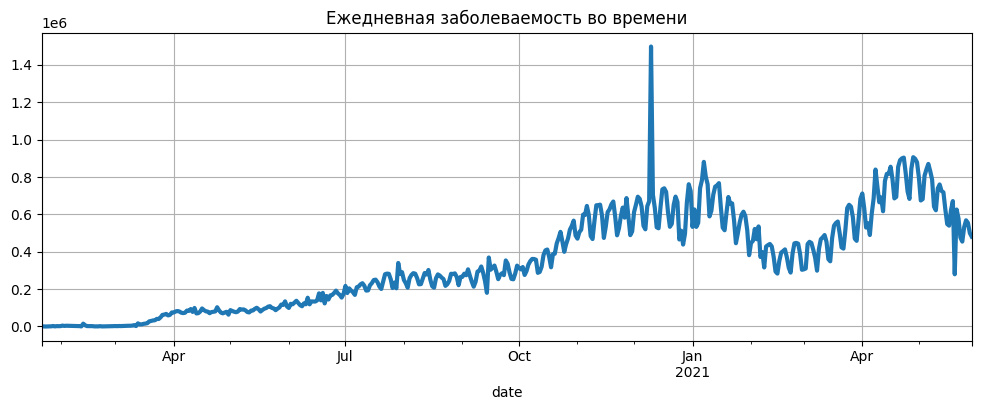

In [12]:
grouped_cases = covid_df.groupby('date')['daily_confirmed'].sum()
grouped_cases.plot(kind='line',figsize=(12,4),title = 'Ежедневная заболеваемость во времени', grid = True, lw= 3)

Теперь построим гистограмму, которая покажет распределение ежедневной заболеваемости во всём мире. Для этого параметр kind выставляем на значение 'hist'. Параметр bins (корзины) отвечает за число прямоугольников в гистограмме — пусть их будет 10 (попробуйте использовать другие числа, чтобы увидеть разницу).


<Axes: title={'center': 'Ежедневная заболеваемость во времени'}, ylabel='Frequency'>

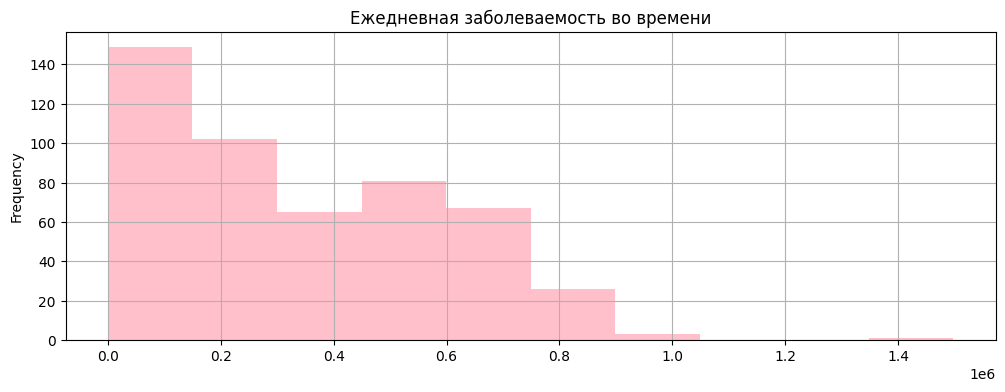

In [29]:
grouped_cases.plot(kind='hist',figsize=(12,4),title = 'Ежедневная заболеваемость во времени', grid = True, color = 'pink', lw= 3)

Для этого сгруппируем данные по странам и вычислим последний зафиксированный показатель с помощью агрегирующего метода last() — он возвращает последнее значение в столбце DataFrame.

Для построения столбчатой диаграммы значение параметра kind выставляем на 'bar'. Параметр colormap отвечает за цветовую гамму графика.


<Axes: xlabel='country'>

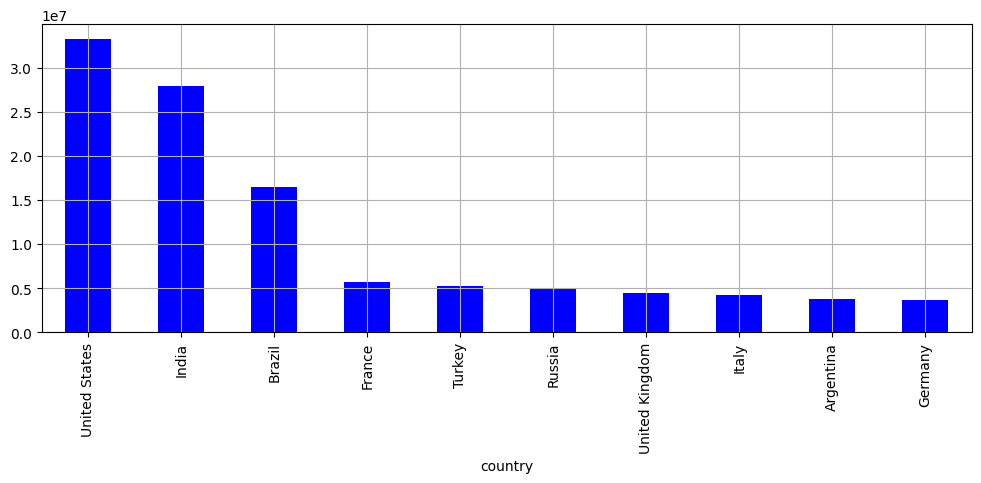

In [ ]:
grouped_country = covid_df.groupby(['country'])['confirmed'].last() # метода last() — он возвращает последнее значение в столбце DataFrame.
grouped_country = grouped_country.nlargest(10)
grouped_country.plot(kind='bar',grid = True,figsize=(12,4), color = 'blue')

А теперь посмотрим, как в этих десяти странах соотносится количество заболевших и умерших от вируса. Для этого отобразим сразу два показателя на столбчатой диаграмме: 

<Axes: xlabel='country'>

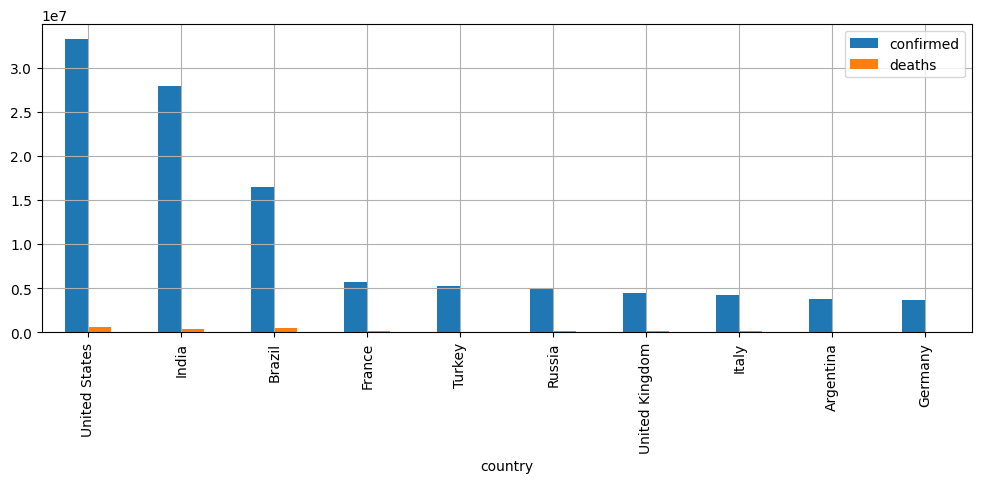

In [30]:
grouped_country = covid_df.groupby(['country'])[['confirmed','deaths']].last() 
# метода last() — он возвращает последнее значение в столбце DataFrame.
grouped_country = grouped_country.nlargest(10, columns = ['confirmed'])
grouped_country.plot (kind='bar', grid = True, figsize = (12,4))


С помощью какого из перечисленных ниже вариантов кода можно построить столбчатую диаграмму для пяти стран с наименьшим общим числом вакцинаций на последний день рассматриваемого периода (total_vaccinations)?


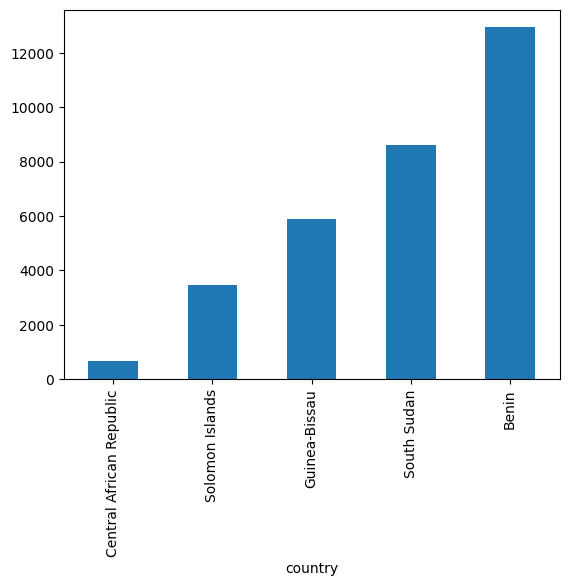

In [34]:
covid_df.groupby(['country'])['total_vaccinations'].last().nsmallest(5).plot(kind='bar');

### 5.Графические возможности библиотеки Matplotlib

In [13]:
import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline 
# Примечание. Если вы используете тёмную тему в VS Code, то для корректного отображения графиков на тёмном 
# фоне выполните следующую команду по установке стиля отображения:
plt.style.use('default') 

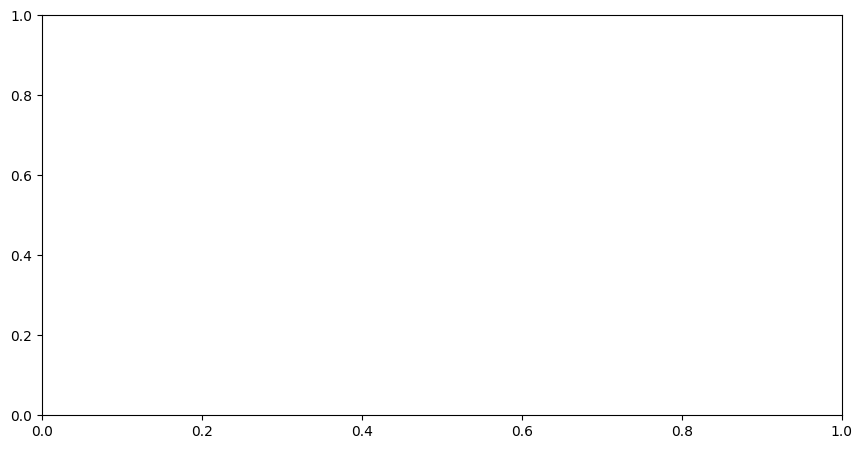

In [14]:
fig = plt.figure(figsize=(8, 4))
axes = fig.add_axes([0, 0, 1, 1])

Утверждается, что коллективная вакцинация позволяет минимизировать риск заражения коронавирусной инфекцией (но только после второго компонента). Давайте проверим это на примере США: построим диаграмму рассеяния, которая покажет зависимость числа ежедневно обнаруживаемых случаев заражения (daily_confirmed) от общего количества привитых вторым компонентом вакцины (people_fully_vaccinated) в США.


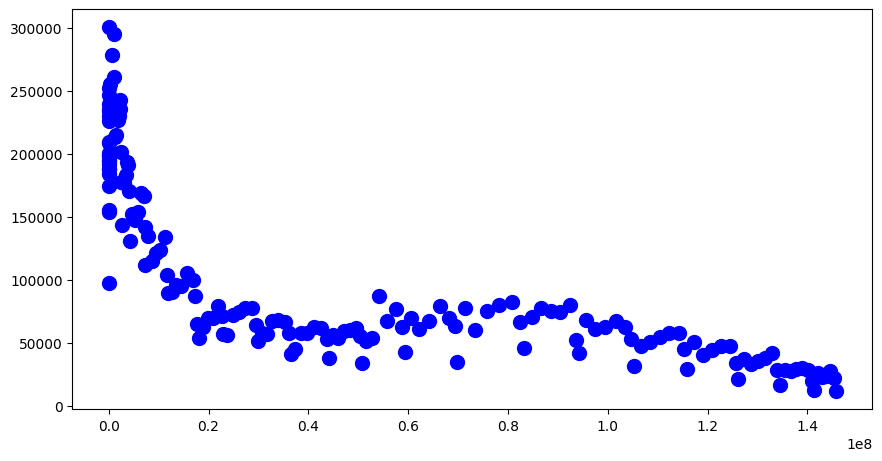

In [7]:
us = covid_df[covid_df['country']=='United States'] 
fig = plt.figure(figsize =(8, 4))
axes = fig.add_axes([0, 0, 1, 1])
axes.scatter(x=us['people_fully_vaccinated'], y = us['daily_confirmed'],s=100, marker = 'o', c = 'blue')


Построим круговую диаграмму, чтобы отобразить ТОП-10 комбинаций вакцин в мире. 
ТОП-10 комбинаций вакцин (vaccines) по распространённости мы находим с помощью метода value_counts(). Круговую диаграмму строим на полученных значениях, метки для каждого значения — индексы промежуточной таблицы. Будем отображать доли в процентах и округлять их до одного знака после запятой. Самую распространённую вакцину сместим на 10 % от центра:

([<matplotlib.patches.Wedge at 0x1c4817adbe0>,
 [Text(0.7248388684778753, 0.9563517212530721, 'Johnson&Johnson, Moderna, Oxford/AstraZeneca, Pfizer/BioNTech'),
  Text(-0.6556959920655523, 0.8832116201619923, 'Johnson&Johnson, Moderna, Novavax, Oxford/AstraZeneca, Pfizer/BioNTech'),
  Text(-1.0627972551057587, 0.2836582354518637, 'Moderna, Oxford/AstraZeneca, Pfizer/BioNTech'),
  Text(-1.037197859594554, -0.36636129715415655, 'Oxford/AstraZeneca, Pfizer/BioNTech'),
  Text(-0.7037196742904196, -0.845445811401645, 'Johnson&Johnson, Moderna, Pfizer/BioNTech'),
  Text(-0.23410886352540727, -1.074799069602706, 'Oxford/AstraZeneca'),
  Text(0.23964234070055868, -1.0735788506409567, 'Oxford/AstraZeneca, Pfizer/BioNTech, Sinopharm/Beijing'),
  Text(0.6334000206000339, -0.899335540220599, 'Oxford/AstraZeneca, Pfizer/BioNTech, Sinovac, Sputnik V'),
  Text(0.9294539598247642, -0.5883156776476943, 'Oxford/AstraZeneca, Pfizer/BioNTech, Sinopharm/Beijing, Sputnik V'),
  Text(1.0814450455397704, -0.20

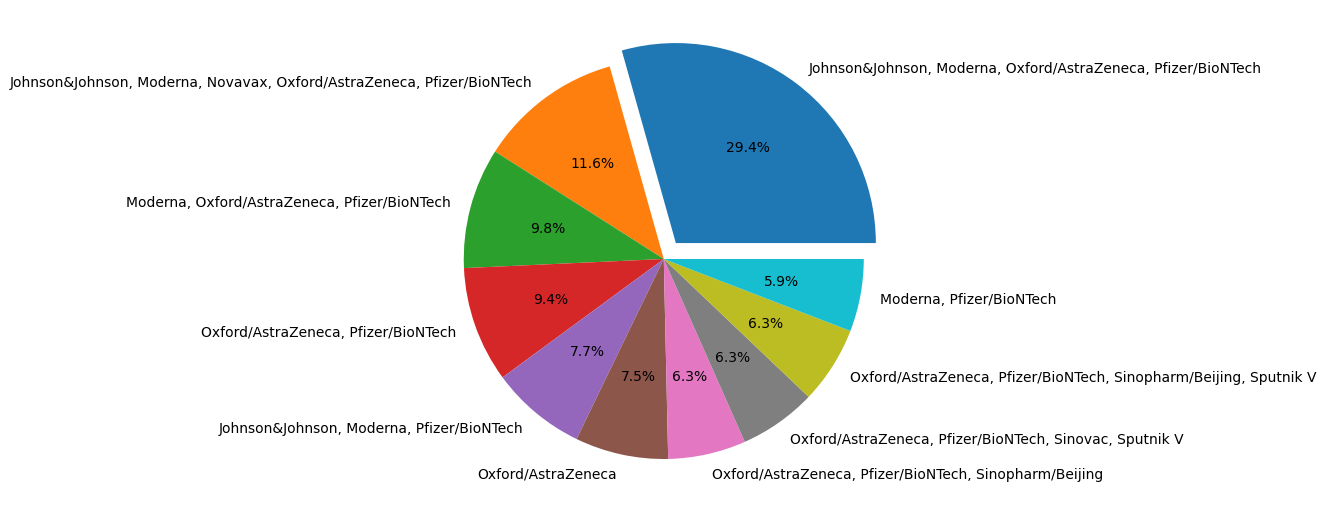

In [8]:
vaccine_combinations = covid_df['vaccines'].value_counts()[:10]
fig = plt.figure(figsize = (5,5))
axes = fig.add_axes([0,0,1,1])
axes.pie(vaccine_combinations, labels = vaccine_combinations.index, autopct='%.1f%%',explode=[0.1,0,0,0,0,0,0,0,0,0])

Например, изобразим на одном графике, как росла общая заболеваемость (confirmed), число зафиксированных смертей (deaths), выздоровевших пациентов (recovered) и активных случаев (active) в Китае.

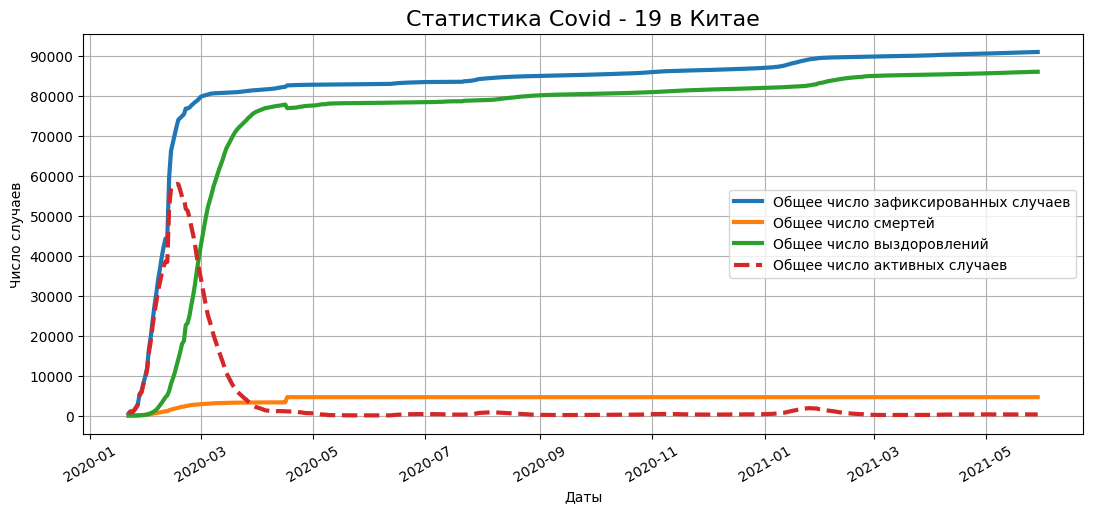

In [9]:
china_data = covid_df[covid_df['country']=='China']
china_grouped = china_data.groupby(['date'])[['confirmed','active','deaths','recovered']].sum()

# визуализация графиков 
fig = plt.figure(figsize=(10,4))
axes = fig.add_axes([0,0,1,1])
axes.plot(china_grouped['confirmed'], label = 'Общее число зафиксированных случаев', lw = 3)
axes.plot(china_grouped['deaths'], label = 'Общее число смертей', lw = 3)
axes.plot(china_grouped['recovered'], label = 'Общее число выздоровлений', lw = 3)
axes.plot(china_grouped['active'], label = 'Общее число активных случаев', lw = 3, linestyle = 'dashed')

# установка параметров отображения 
axes.set_title('Статистика Covid - 19 в Китае', fontsize = 16)
axes.set_xlabel('Даты')
axes.set_ylabel('Число случаев')
axes.set_yticks(range(0,100000,10000))
axes.xaxis.set_tick_params(rotation=30)
axes.grid()
axes.legend()


Например, отобразим ТОП-5 стран по общему числу привитых вторым компонентом людей (people_fully_vaccinated), а также ТОП-5 стран по числу полностью привитых на 100 человек населения (people_fully_vaccinated_per_hundred).


Группируем таблицу по странам, находим последний по дате зафиксированный показатель с помощью метода last() и выбираем ТОП-5 стран с использованием метода nlargest().

При отображении графиков создаём две координатные плоскости main_axes и insert_axes, на каждой из них отдельно строим столбчатые диаграммы.

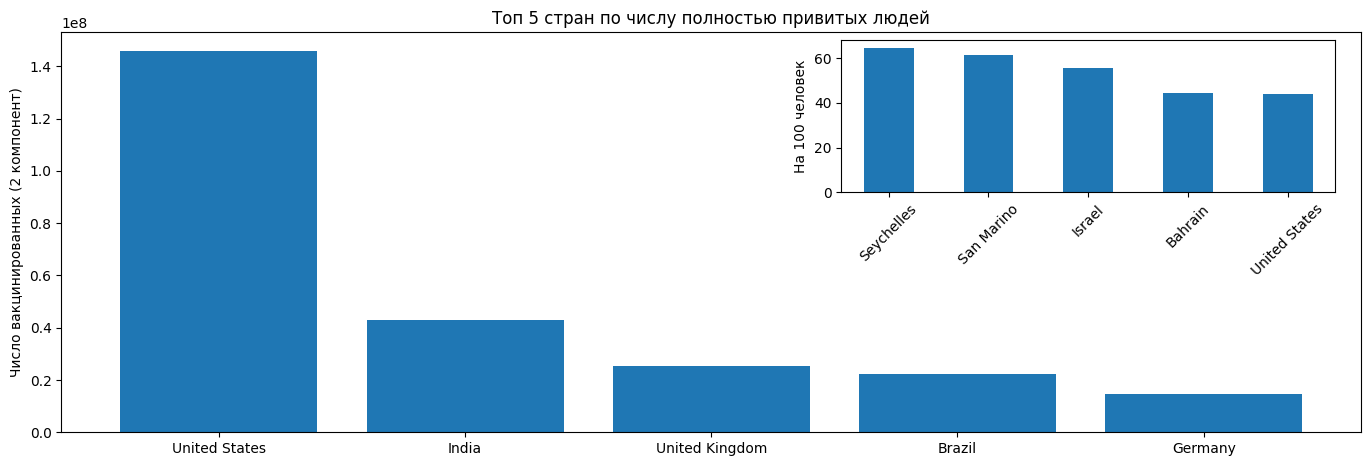

In [10]:
vacc_country = covid_df.groupby('country')['people_fully_vaccinated'].last().nlargest(5)
vacc_country_per_hundred = covid_df.groupby('country')['people_fully_vaccinated_per_hundred'].last().nlargest(5)

#визуализация главного графика
fig = plt.figure(figsize=(13, 4))
main_axes = fig.add_axes([0, 0, 1, 1])
main_axes.bar(x = vacc_country.index, height = vacc_country);
main_axes.set_ylabel('Число вакцинированных (2 компонент)')
main_axes.set_title('Топ 5 стран по числу полностью привитых людей')

#визуализация вспомогательного графика
insert_axes = fig.add_axes([0.6, 0.6, 0.38, 0.38])
insert_axes.bar(x = vacc_country_per_hundred.index, height = vacc_country_per_hundred, width=0.5);
insert_axes.set_ylabel('На 100 человек')
insert_axes.xaxis.set_tick_params(rotation=45)

Теперь, обладая знаниями о методе subplots(), построим три графика:

Столбчатую диаграмму, которая покажет динамику ежедневной вакцинации в России.
Линейный график изменения ежедневной заболеваемости в стране.
Гистограмму ежедневной заболеваемости в стране.
За построение гистограмм в библиотеке Matplotlib отвечает метод hist().

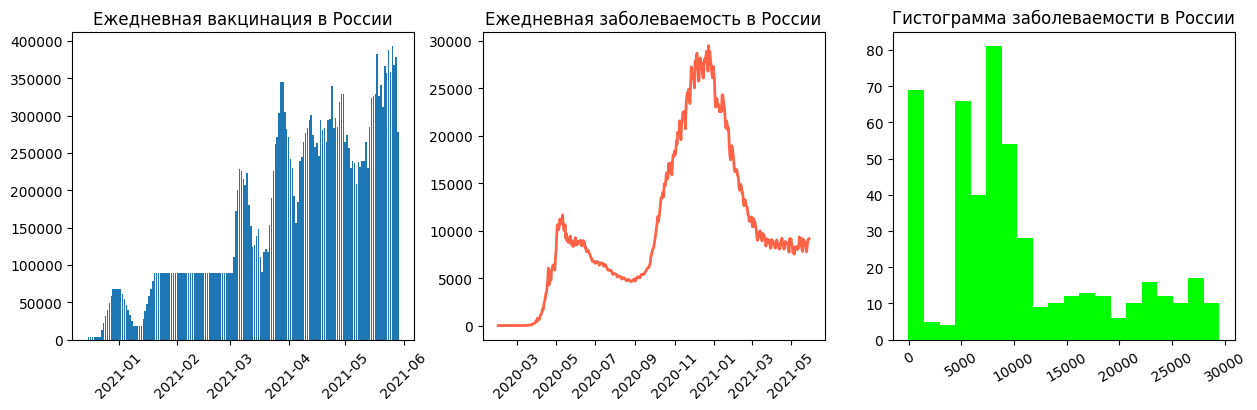

In [11]:
russia_data = covid_df[covid_df["country"] == "Russia"]

# визуализация систем координат
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

# столбчатая диаграмма
axes[0].bar(x=russia_data["date"],height=russia_data["daily_vaccinations"],label="Число вакцинированных")
axes[0].set_title("Ежедневная вакцинация в России")
axes[0].xaxis.set_tick_params(rotation=45)

# линейный график
axes[1].plot(russia_data["date"],russia_data["daily_confirmed"],label="Число заболевших",color="tomato",lw=2)
axes[1].set_title("Ежедневная заболеваемость в России")
axes[1].xaxis.set_tick_params(rotation=45)

# гистограмма
axes[2].hist(x=russia_data["daily_confirmed"], label=["Число заболевших"], color="lime", bins=20)
axes[2].set_title("Гистограмма заболеваемости в России")
axes[2].xaxis.set_tick_params(rotation=30)

### 6. Графические возможности библиотеки Seaborn

⭐ А теперь снова немного магии Feature Engineering, чтобы показатели по странам стали сопоставимыми: добавим информацию о населении стран, чтобы рассчитать ежедневную заболеваемость на 100 человек — заболеваемость в процентах от общего количества населения (daily_confirmed_per_hundred).

In [17]:
import seaborn as sns 
print(sns.__version__)



countries = ['Russia','Australia','Germany','Canada','United Kingdom']
croped_covid_df = covid_df[covid_df['country'].isin(countries)]
populations = pd.DataFrame([['Canada',37664517],['Germany',83721496],
                            ['Russia',145975300],['Australia',25726900],['United Kingdom',67802690]],
                           columns=['country','population'])
croped_covid_df = croped_covid_df.merge(populations, on =['country'])
croped_covid_df['daily_confirmed_per_hundred'] = croped_covid_df['daily_confirmed']/croped_covid_df['population']*100

croped_covid_df.head()



0.13.2


,date,country,confirmed,deaths,recovered,active,daily_confirmed,daily_deaths,daily_rescovered,total_vaccinations,people_vaccinated,people_vaccinated_per_hundred,people_fully_vaccinated,people_fully_vaccinated_per_hundred,daily_vaccinations,vaccines,population,daily_confirmed_per_hundred
0,2020-01-23,Australia,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,NaN
1,2020-01-25,Australia,4.0,0.0,0.0,4.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,0.000016
2,2020-01-26,Australia,4.0,0.0,0.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,0.000000
3,2020-01-27,Australia,5.0,0.0,0.0,5.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,0.000004
4,2020-01-28,Australia,5.0,0.0,0.0,5.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,0.000000


Построим сразу две гистограммы: одна будет иллюстрировать общее распределение ежедневной заболеваемости (daily_confirmed), а вторая — то же распределение в разрезе стран. 

Для этого создаём две координатные плоскости с помощью метода subplots(). 

На первой координатной плоскости рисуем простую гистограмму с 25 столбцами, а также добавим на неё сглаживающую кривую. 

На второй гистограмме добавляем параметр названия страны по оси y. В таком случае количество наблюдений будет обозначаться на диаграмме яркостью цвета (чем темнее полоса, тем больше наблюдений находится в интервале).

<Axes: xlabel='daily_confirmed_per_hungred', ylabel='country'>

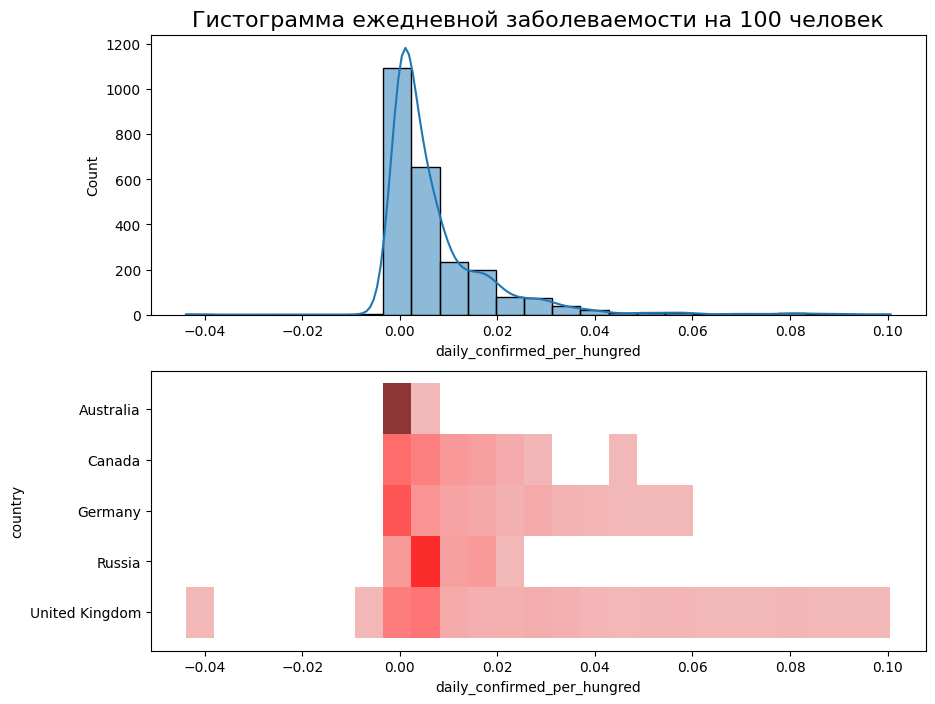

In [73]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10,8))
sns.histplot(data=croped_covid_df, x = 'daily_confirmed_per_hungred',bins = 25, kde = True, ax=axes[0])
axes[0].set_title('Гистограмма ежедневной заболеваемости на 100 человек',fontsize = 16)
sns.histplot(data = croped_covid_df, x = 'daily_confirmed_per_hungred', y = 'country', bins = 25, color = 'red', ax = axes[1])

Вывыод: 
Общая гистограмма показывает, что ежедневная заболеваемость в выбранных странах не превышает 0.1 % от общего количества населения, причём большая часть наблюдений сосредоточена около 0. 

Также отчётливо видны аномалии — маленькие «пеньки», где заболеваемость отрицательная.

Гистограмма по странам показывает, какой вклад в общее распределение вносит заболеваемость в каждой из стран по отдельности. Например, ясно, что пик около нуля на общей гистограмме в основном задаётся Австралией, так как в ней ежедневная заболеваемость не превышала 0.005 % от общего числа населения (около 1.5 тыс. человек в день) и все наблюдения сосредоточены в двух интервалах. Чуть больший разброс по числу фиксируемых в день случаев имеет Россия, затем идут Канада, Германия и Великобритания.

Отличительной особенностью распределения для России и Великобритании является то, что для них характерен больший процент заболевших (самая тёмная отметка находится правее, чем у других стран).

Наконец, видно, что аномальная отрицательная заболеваемость принадлежит Великобритании. Об аномалиях, их поиске как с помощью визуализации, так и иными методами мы ещё будем говорить в модуле по очистке данных.

Рассмотрим пример — построим коробчатые диаграммы признака летальности (death_rate), который вы создавали ранее в задании 3.3.

Ящики отразим горизонтально (для этого по оси x отложим признак летальности, а по оси y — страны), параметр orient отвечает за ориентацию диаграммы, а width — за ширину коробок:

In [18]:
#croped_covid_df = croped_covid_df.groupby(['country'],as_index=False)[['confirmed','deaths','recovered']].sum()

croped_covid_df['death_rate'] = (croped_covid_df['deaths'])/(croped_covid_df['confirmed'])*100

croped_covid_df['recover_rate'] = (croped_covid_df['recovered'])/(croped_covid_df['confirmed'])*100

croped_covid_df


,date,country,confirmed,deaths,recovered,active,daily_confirmed,daily_deaths,daily_rescovered,total_vaccinations,people_vaccinated,people_vaccinated_per_hundred,people_fully_vaccinated,people_fully_vaccinated_per_hundred,daily_vaccinations,vaccines,population,daily_confirmed_per_hundred,death_rate,recover_rate
0,2020-01-23,Australia,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,NaN,NaN,NaN
1,2020-01-25,Australia,4.0,0.0,0.0,4.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,0.000016,0.000000,0.000000
2,2020-01-26,Australia,4.0,0.0,0.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,0.000000,0.000000,0.000000
3,2020-01-27,Australia,5.0,0.0,0.0,5.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,0.000004,0.000000,0.000000
4,2020-01-28,Australia,5.0,0.0,0.0,5.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25726900,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2435,2021-05-25,United Kingdom,4483177.0,128001.0,15453.0,4339723.0,2417.0,15.0,8.0,61995062.0,38378564.0,56.27,23616498.0,34.62,591301.0,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",67802690,0.003565,2.855140,0.344689
2436,2021-05-26,United Kingdom,4486168.0,128010.0,15477.0,4342681.0,2991.0,9.0,24.0,62658639.0,38614683.0,56.61,24043956.0,35.25,595544.0,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",67802690,0.004411,2.853437,0.344994
2437,2021-05-27,United Kingdom,4489552.0,128020.0,15480.0,4346052.0,3384.0,10.0,3.0,63349252.0,38871200.0,56.99,24478052.0,35.89,595836.0,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",67802690,0.004991,2.851509,0.344801
2438,2021-05-28,United Kingdom,4493582.0,128030.0,15480.0,4350072.0,4030.0,10.0,0.0,63989645.0,39075642.0,57.29,24914003.0,36.53,594987.0,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",67802690,0.005944,2.849175,0.344491


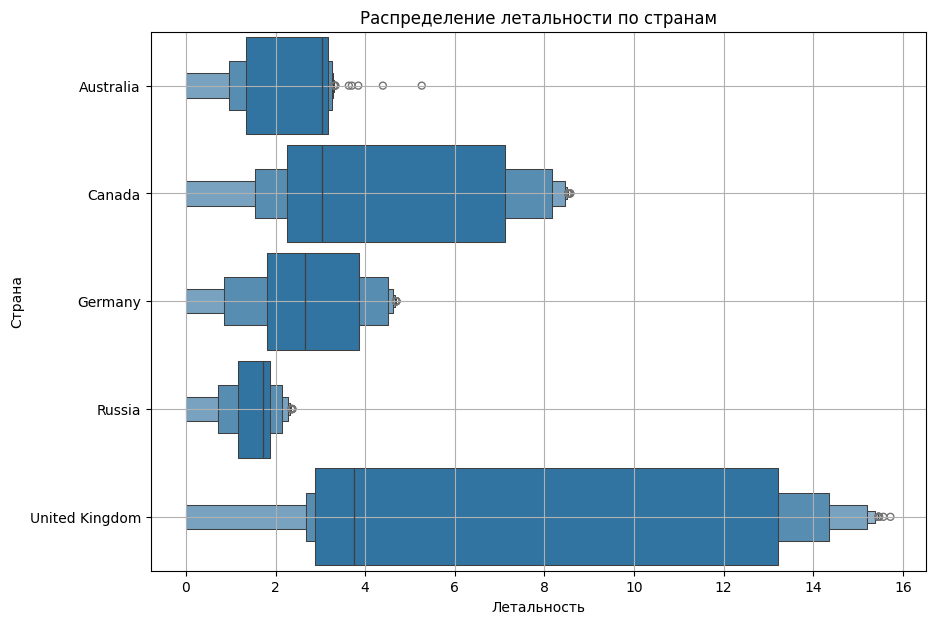

In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns 

fig = plt.figure(figsize = (10,7))
boxplot = sns.boxenplot(data=croped_covid_df, y='country', x = 'death_rate', orient = 'h', width= 0.9)
boxplot.set_title('Распределение летальности по странам')
boxplot.set_xlabel('Летальность')
boxplot.set_ylabel('Страна')
boxplot.grid()

Теперь рассмотрим пример многоуровневой столбчатой диаграммы. С помощью неё мы можем, например, посмотреть на средний ежедневный процент заболевших в странах по кварталам.

Text(0.5, 1.0, 'Средний процент болеющего населения по кварталам')

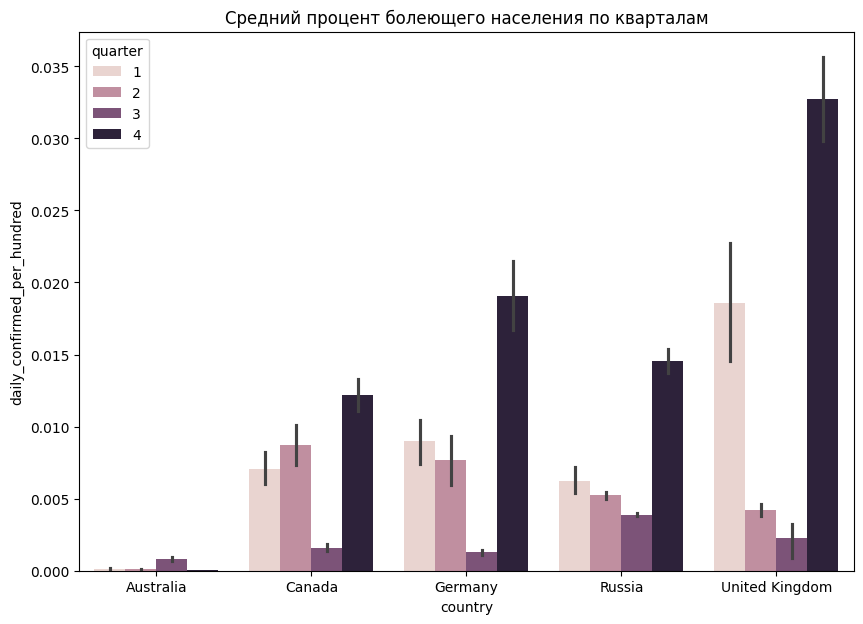

In [106]:
fig = plt.figure(figsize=(10,7))
croped_covid_df['quarter'] = croped_covid_df['date'].dt.quarter
barplot = sns.barplot(data = croped_covid_df, x='country',y='daily_confirmed_per_hundred',hue='quarter')
barplot.set_title('Средний процент болеющего населения по кварталам')


Построим jointplot зависимости ежедневной заболеваемости в странах от общей численности населения в процентах (daily_confirmed_per_hundred) от числа полностью вакцинированных в процентах (people_fully_vaccinated_per_hundred).

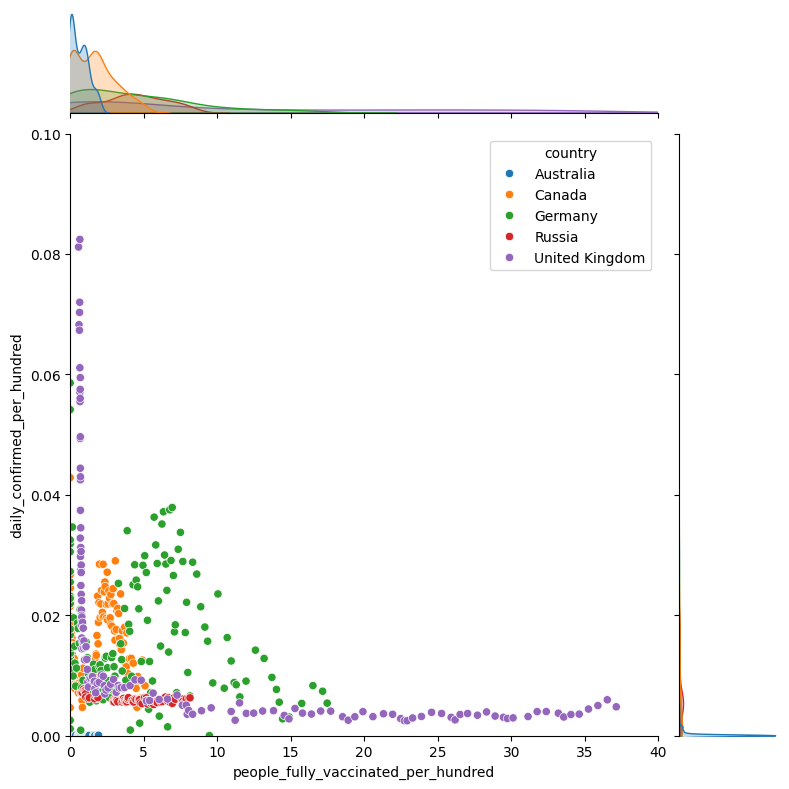

In [110]:
jointplot = sns.jointplot(data=croped_covid_df,x='people_fully_vaccinated_per_hundred',
                          y='daily_confirmed_per_hundred', hue ='country',
                          xlim = (0,40),
                          ylim=(0,0.1),
                          height=8)


Задача: 

Допустим, мы хотим сравнить темпы вакцинации по странам во времени. Вы, скорее всего, сразу подумали о линейном графике. Но давайте мыслить шире. Когда мы хотим сравнить скорость изменения показателей по малому количеству категорий (в данном случае — по странам, а их у нас их всего пять), нагляднее всего будет тепловая карта.

Решение 

Предварительно создадим сводную таблицу: по столбцам отложим признак даты, а по строкам — страны. В ячейках таблицы будет находиться процент вакцинированных (первым компонентом) людей в стране на определённую дату. Чтобы даты отображались на тепловой карте верно, их необходимо привести к типу string.

In [112]:
pivot = croped_covid_df.pivot_table(values='people_vaccinated_per_hundred',columns='date',index = 'country')
pivot.columns = pivot.columns.astype('string')
display(pivot)

date,2020-12-14,2020-12-15,2020-12-16,2020-12-17,2020-12-18,2020-12-19,2020-12-20,2020-12-21,2020-12-22,2020-12-23,...,2021-05-20,2021-05-21,2021-05-22,2021-05-23,2021-05-24,2021-05-25,2021-05-26,2021-05-27,2021-05-28,2021-05-29
country,,,,,,,,,,,,,,,,,,,,,
Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.78,NaN,NaN,NaN,12.62,12.88,13.28,13.73,14.18,14.40
Canada,0.0,0.00,0.01,0.02,0.03,0.03,0.03,0.06,0.07,0.09,...,48.41,49.55,50.44,51.20,52.08,52.69,53.40,54.27,55.29,56.02
Germany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,39.29,39.79,40.06,40.22,40.40,40.76,41.41,41.99,42.52,42.73
Russia,NaN,0.02,NaN,NaN,NaN,NaN,NaN,NaN,0.04,NaN,...,10.20,10.30,10.50,10.53,10.70,10.81,11.07,11.12,11.19,11.29
United Kingdom,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55.01,55.33,55.63,55.82,55.99,56.27,56.61,56.99,57.29,57.56


Text(0.5, 1.0, 'Тепловая карта вакцинации')

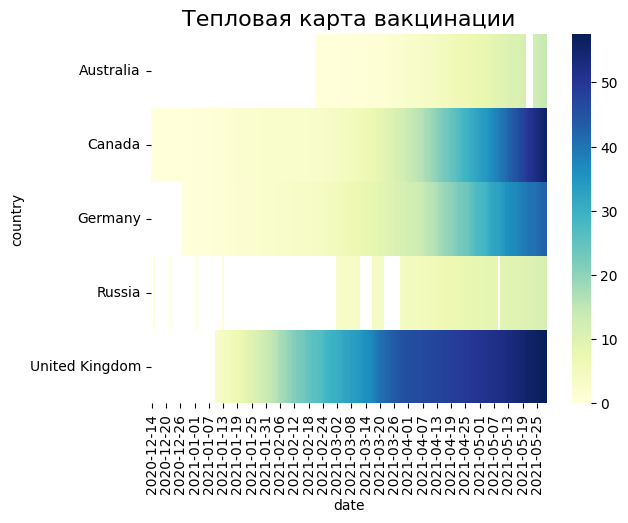

In [123]:
heatmap=sns.heatmap(data=pivot, cmap = 'YlGnBu')
heatmap.set_title('Тепловая карта вакцинации', fontsize = 16)

Задание 6.4

Создайте новый признак confirmed_per_hundred, который покажет процентное отношение заболевших вирусом к общему числу населения в странах ().
Постройте тепловую карту, которая покажет, как росло число заболевших в процентах от общего числа населения (confirmed_per_hundred) в странах из таблицы croped_covid_df.
Выберите верные выводы по построенному графику:

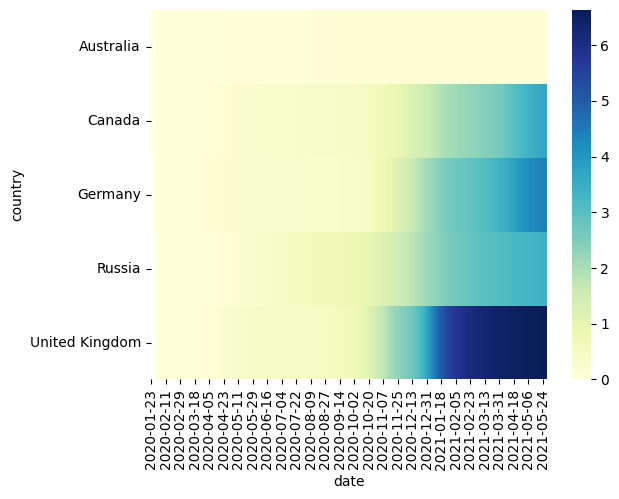

In [132]:
croped_covid_df['confirmed_per_hundred']=croped_covid_df['confirmed']/croped_covid_df['population']*100

heatmap_data = croped_covid_df.pivot_table(values='confirmed_per_hundred', index='country', columns='date')
#display(heatmap_data)
heatmap_data.columns=heatmap_data.columns.astype('string')
heatmap_1 = sns.heatmap(data=heatmap_data,cmap = 'YlGnBu')
#croped_covid_df

Задание 6.5

Постройте коробчатую диаграмму для признака recover_rate (отношение выздоровлений к числу зафиксированных случаев заболевания в процентах).
Выберите верные выводы по данному графику:

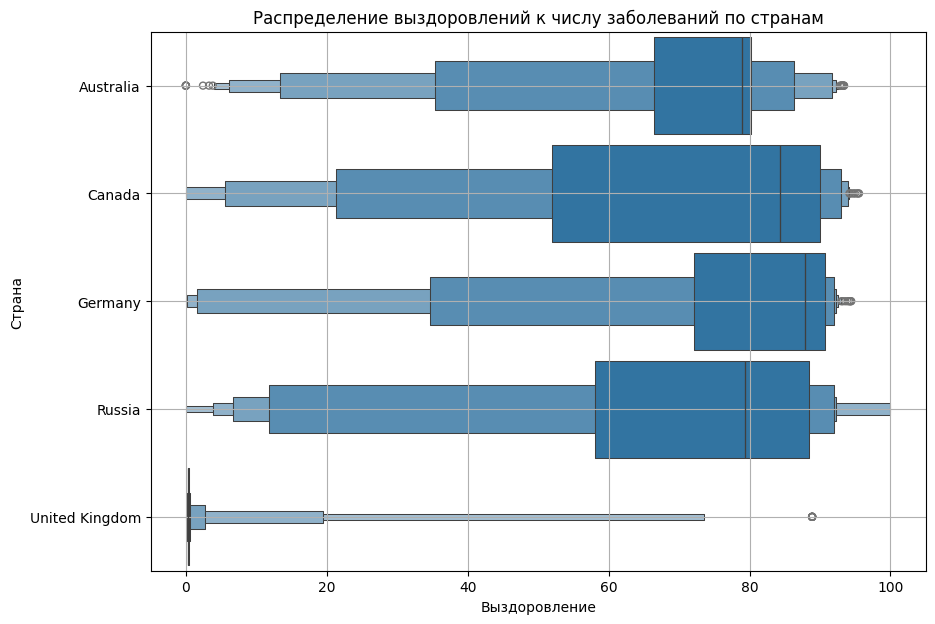

In [141]:
croped_covid_df['recover_rate']=croped_covid_df['recovered']/croped_covid_df['confirmed']*100

fig = plt.figure(figsize = (10,7))
boxplot = sns.boxenplot(data=croped_covid_df, y='country', x = 'recover_rate', orient = 'h', width= 0.9,)
boxplot.set_title('Распределение выздоровлений к числу заболеваний по странам')
boxplot.set_xlabel('Выздоровление')
boxplot.set_ylabel('Страна')
boxplot.grid()

In [135]:
croped_covid_df

,date,country,confirmed,deaths,recovered,active,daily_confirmed,daily_deaths,daily_rescovered,total_vaccinations,...,people_vaccinated_per_hundred,people_fully_vaccinated,people_fully_vaccinated_per_hundred,daily_vaccinations,vaccines,population,daily_confirmed_per_hundred,quarter,confirmed_per_hundred,recover_rate
0,2020-01-23,Australia,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,25726900,NaN,1,0.000000,NaN
1,2020-01-25,Australia,4.0,0.0,0.0,4.0,4.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,25726900,0.000016,1,0.000016,0.000000
2,2020-01-26,Australia,4.0,0.0,0.0,4.0,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,25726900,0.000000,1,0.000016,0.000000
3,2020-01-27,Australia,5.0,0.0,0.0,5.0,1.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,25726900,0.000004,1,0.000019,0.000000
4,2020-01-28,Australia,5.0,0.0,0.0,5.0,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,25726900,0.000000,1,0.000019,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2435,2021-05-25,United Kingdom,4483177.0,128001.0,15453.0,4339723.0,2417.0,15.0,8.0,61995062.0,...,56.27,23616498.0,34.62,591301.0,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",67802690,0.003565,2,6.612093,0.344689
2436,2021-05-26,United Kingdom,4486168.0,128010.0,15477.0,4342681.0,2991.0,9.0,24.0,62658639.0,...,56.61,24043956.0,35.25,595544.0,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",67802690,0.004411,2,6.616504,0.344994
2437,2021-05-27,United Kingdom,4489552.0,128020.0,15480.0,4346052.0,3384.0,10.0,3.0,63349252.0,...,56.99,24478052.0,35.89,595836.0,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",67802690,0.004991,2,6.621495,0.344801
2438,2021-05-28,United Kingdom,4493582.0,128030.0,15480.0,4350072.0,4030.0,10.0,0.0,63989645.0,...,57.29,24914003.0,36.53,594987.0,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech",67802690,0.005944,2,6.627439,0.344491


### 7. Графические возможности библиотеки Plotly

In [148]:
import plotly 
import plotly.express as px

display(plotly.__version__)

'6.7.0'

Рассмотрим процесс визуализации на примере. Посмотрим, как выглядит линейный график, построенный с помощью метода line() из модуля express. В документации к методу приведена пара десятков его параметров (они схожи с параметрами других методов) — мы приведём основные из них.


Построим график роста зафиксированного числа случаев заражения (confirmed), смертей (deaths), выздоровлений (recovered) и активных случаев (active) за всё время. Для этого просуммируем статистику по дням и передадим полученный DataFrame в метод line().

Для отображения созданной методом line() фигуры используется метод fig.show():

In [151]:
line_data = covid_df.groupby('date', as_index = False).sum()
fig = px.line(data_frame = line_data, x = 'date', y=['confirmed','recovered','deaths','active'],
              height = 500, width=1000, 
              title='Зараженные, выздоровевшие, умершие - на протяжении периода')
fig.show()

Пример 2 
Давайте рассмотрим ещё один пример — построим столбчатую диаграмму, показывающую ТОП-10 стран по среднему проценту выздоравливающих пациентов (recover_rate). Для этого используем метод bar() модуля express. Добавим несколько параметров:

color — группирующий признак, в соответствии с которым будут раскрашены столбцы диаграммы;
text — текст, который будет подписан на столбцах диаграммы;
orientation — ориентация графика ('v' — вертикальная, 'h' — горизонтальная).

In [158]:
covid_df['recover_rate']=covid_df['recovered']/covid_df['confirmed']*100
bar_data = covid_df.groupby(by = 'country', as_index = False)[['recover_rate']].mean().round(2).nlargest(10,
                                            columns = ['recover_rate'])

fig = px.bar(data_frame=bar_data, x = 'country', y = 'recover_rate', color = 'country', 
             text = 'recover_rate', orientation='v',height =500, width =1000, 
             title ='Топ-10 стран по частоте выздоровления среди заболевших ковидом')
fig.show()


А теперь давайте построим что-нибудь, специфичное для библиотеки Plotly. Например, график treemap() (древесная, или иерархическая, диаграмма). Такой график используется для исследования показателя, когда число возможных категорий велико (например, число стран в таблице covid_df).

Но, как говорится, лучше один раз увидеть, чем сто раз прочитать. Построим иерархическую диаграмму для среднего ежедневного показателя выздоровевших пациентов (daily_recovered) во всех странах.

In [28]:
covid_df

,date,country,confirmed,deaths,recovered,active,daily_confirmed,daily_deaths,daily_rescovered,total_vaccinations,people_vaccinated,people_vaccinated_per_hundred,people_fully_vaccinated,people_fully_vaccinated_per_hundred,daily_vaccinations,vaccines
0,2020-02-24,Afghanistan,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-25,Afghanistan,1.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-26,Afghanistan,1.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-27,Afghanistan,1.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-28,Afghanistan,1.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86780,2020-03-12,occupied Palestinian territory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86781,2020-03-14,occupied Palestinian territory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86782,2020-03-15,occupied Palestinian territory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86783,2020-03-16,occupied Palestinian territory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
import plotly.express as px

treemap_data = covid_df.groupby(by='country', as_index = False)[['daily_rescovered']].mean()
fig = px.treemap(data_frame = treemap_data, path =['country'], values = 'daily_rescovered', height=500, width=1000, 
                 title = 'Дневное выздоровление по странам')
fig.show()


Итак, построим фоновую картограмму, которая покажет распространение (confirmed) коронавируса в мире во времени.

Предварительно для правильного отображения на анимационном бегунке даты в таблице covid_df необходимо перевести обратно в строковый тип данных.

In [37]:
import plotly 
import plotly.express as px
# преобразуем даты в строковый формат 
choropleth_data = covid_df.sort_values(by='date')
choropleth_data['date']=choropleth_data['date'].astype('string')

# строим график 
fig = px.choropleth(
    data_frame=choropleth_data,
    locations = 'country',
    locationmode = 'country names',
    color = 'confirmed',
    animation_frame= 'date', 
    range_color=[0,30e6], 
    title='Глобальный спред по ковиду 19', 
    width=800, 
    height=500, 
    color_continuous_scale='Reds'
)
fig.show()

C:\Users\rus-l\AppData\Local\Temp\ipykernel_28724\1000294215.py:8: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


Построим 3D-диаграмму рассеяния, которая покажет, как число ежедневно обнаруживаемых случаев и число ежедневных смертей влияют на желание людей вакцинироваться. Для того чтобы нам было проще рассматривать диаграмму (точки будут более сгруппированными), построим её в логарифмическом масштабе по осям абсцисс и ординат.

In [44]:
# фильтруем таблицу по странам 
countries = ['United States', 'Russia', 'United Kingdom','Brazil','France']
scatter_data = covid_df[covid_df['country'].isin(countries)]

# строим график 
fig = px.scatter_3d(
    data_frame=scatter_data, 
    x='daily_confirmed',
    y='daily_deaths',
    z='daily_vaccinations',
    color='country',
    log_x=True,
    log_y=True,
    width=1000,
    height=700
)
fig.show()
fig.write_html('plotly/scatter_3d.html')


Задание 7.5

Постройте линейный график, который отображает, как изменялось ежедневное количество вакцинированных (daily_vaccinations) в мире во времени. Из графика найдите, чему равно количество вакцинированных (в миллионах) 28 февраля 2021 года (2021-02-28). Ответ округлите до целого числа.

In [45]:
line_data = covid_df.groupby('date', as_index = False).sum()
fig = px.line(data_frame = line_data, x = 'date', y=['daily_vaccinations'],
              height = 500, width=1000, 
              title='Число вакценированных на протяжении периода')
fig.show()

Задание 7.6

Постройте анимированную тепловую картограмму для числа поставленных вакцин во всём мире (total_vaccinations). На полученной карте найдите, чему равно количество вакцинированных в Японии (Japan) на 24 марта 2021 года (2021-03-24). Ответ приведите в тысячах (без нулей) и округлите до целого числа.
Примечание. Если в j

In [47]:
import plotly 
import plotly.express as px
# преобразуем даты в строковый формат 
choropleth_data = covid_df.sort_values(by='date')
choropleth_data['date']=choropleth_data['date'].astype('string')

# строим график 
fig = px.choropleth(
    data_frame=choropleth_data,
    locations = 'country',
    locationmode = 'country names',
    color = 'total_vaccinations',
    animation_frame= 'date', 
    range_color=[0,30e6], 
    title='Постановка вакцин населению по времени во всем мире', 
    width=800, 
    height=500, 
    color_continuous_scale='Reds'
)
fig.show()

C:\Users\rus-l\AppData\Local\Temp\ipykernel_28724\2291594514.py:8: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


### 9. Закрепление знаний



Столбцы таблицы:

1. RowNumber — номер строки таблицы (это лишняя информация, поэтому можете сразу от неё избавиться)
2. CustomerId — идентификатор клиента
3. Surname — фамилия клиента
4. CreditScore — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их)
5. Geography — страна клиента (банк международный)
6. Gender — пол клиента
7. Age — возраст клиента 
8. Tenure — сколько лет клиент пользуется услугами банка
9. Balance — баланс на счетах клиента в банке
10. NumOfProducts — количество услуг банка, которые приобрёл клиент
11. HasCrCard — есть ли у клиента кредитная карта (1 — да, 0 — нет)
12. IsActiveMember — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет)
13. EstimatedSalary — предполагаемая заработная плата клиента
14. Exited — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)

RowNumber—corresponds to the record (row) number and has no effect on the output.
* CustomerId—contains random values and has no effect on customer leaving the bank.
* Surname—the surname of a customer has no impact on their decision to leave the bank.
* CreditScore—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank.
* Geography—a customer’s location can affect their decision to leave the bank.
* Gender—it’s interesting to explore whether gender plays a role in a customer leaving the bank.
* Age—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.
* Tenure—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.
* Balance—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.
* NumOfProducts—refers to the number of products that a customer has purchased through the bank.
* HasCrCard—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.
* IsActiveMember—active customers are less likely to leave the bank.
* EstimatedSalary—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.
* Exited—whether or not the customer left the bank.


Задача: Итак, банк обращается к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов, но для этого ему необходимо, чтобы вы выяснили основные причины оттока клиентов. Иными словами, нужно установить, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов.
После разведывательного анализа, с целью выявления наиболее важных признаков оттока, банк сможет построить модель машинного обучения, которая будет прогнозировать уход клиента. 